# AnanthiX AI - Jalon 2 : Evaluation Complète

**Objectif** : Analyser les erreurs du modèle baseline


In [1]:
import json
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import pickle
import tensorflow_datasets as tfds
from google.colab import drive

# Setup
drive.mount('/content/drive', force_remount=False)
BASE_PATH = Path('/content/drive/MyDrive/AnanthiX_AI')
DATA_PATH = BASE_PATH / 'data'
RESULTS_PATH = BASE_PATH / 'results'
MODELS_PATH = BASE_PATH / 'models'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ÉTAPE 1 : Charger metadata et dataset

print('Chargement metadata')
with open(DATA_PATH / 'plantvillage_metadata.json', 'r') as f:
    metadata = json.load(f)

class_names = metadata['class_names']
num_classes = len(class_names)

print(f'✓ Classes: {num_classes}')

# Charger dataset
print('\nChargement dataset')
ds, info = tfds.load('plant_village', with_info=True, as_supervised=True)
train_ds = ds['train']

all_images = []
all_labels = []

for i, (image, label) in enumerate(train_ds):
    all_images.append(image.numpy().astype(np.uint8))
    all_labels.append(label.numpy())
    if (i + 1) % 10000 == 0:
        print(f'  {i + 1}/54303')

all_images = np.array(all_images)
all_labels = np.array(all_labels)

print(f' Dataset chargé')

# ÉTAPE 2 : Recréer splits

print('\nCréation splits')

train_indices = []
val_indices = []
test_indices = []

for class_idx in range(num_classes):
    mask = all_labels == class_idx
    indices = np.where(mask)[0]
    n = len(indices)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)

    train_indices.extend(indices[:n_train])
    val_indices.extend(indices[n_train:n_train + n_val])
    test_indices.extend(indices[n_train + n_val:])

print(f'✓ Splits créés')

# ÉTAPE 3 : Recréer DataLoader test

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

class FastDataset(Dataset):
    def __init__(self, images, labels, indices, transform=None):
        self.images = images
        self.labels = labels
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        image = self.images[actual_idx]
        label = self.labels[actual_idx]

        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)

        return image, label

test_dataset = FastDataset(all_images, all_labels, test_indices, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=48, shuffle=False, num_workers=2, pin_memory=True)

print(f'✓ Test loader créé: {len(test_loader)} batches')

# ÉTAPE 4 : Charger modèle entraîné

print('\nChargement modèle')

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(2048, num_classes)
model.load_state_dict(torch.load(MODELS_PATH / 'resnet50_baseline.pth'))
model = model.to(device)
model.eval()

print(f'✓ Modèle chargé')

# ÉTAPE 5 : Évaluation complète + prédictions

print('\nÉvaluation complète')

all_preds = []
all_labels_true = []
all_confidence = []
all_images_wrong = []
all_wrong_preds = []
all_wrong_truths = []
all_wrong_conf = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels_true.extend(labels.numpy())
        all_confidence.extend(confidence.cpu().numpy())

        # Stocker images mal classées
        wrong_mask = predicted.cpu().numpy() != labels.numpy()
        if wrong_mask.any():
            for i, is_wrong in enumerate(wrong_mask):
                if is_wrong:
                    all_images_wrong.append(images[i].cpu())
                    all_wrong_preds.append(predicted[i].item())
                    all_wrong_truths.append(labels[i].item())
                    all_wrong_conf.append(confidence[i].item())

all_preds = np.array(all_preds)
all_labels_true = np.array(all_labels_true)
all_confidence = np.array(all_confidence)

accuracy = 100 * np.mean(all_preds == all_labels_true)
print(f'✓ Accuracy: {accuracy:.2f}%')

# ÉTAPE 6 : Créer confusion matrix

print('\nCréation confusion matrix')

cm = confusion_matrix(all_labels_true, all_preds)

# Visualiser (troncqué pour lisibilité)
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True, ax=ax, xticklabels=False, yticklabels=False)
ax.set_xlabel('Prédiction', fontsize=12)
ax.set_ylabel('Vérité', fontsize=12)
ax.set_title('Confusion Matrix - PlantVillage (38×38)', fontsize=14, fontweight='bold')

cm_path = RESULTS_PATH / 'confusion_matrix_full.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.close()

print(f'✓ Confusion matrix sauvegardée: {cm_path}')

# ÉTAPE 7 : Per-class metrics

print('\nCálcul per-class metrics')

per_class_metrics = {}

for class_idx in range(num_classes):
    tp = cm[class_idx, class_idx]
    fp = cm[:, class_idx].sum() - tp
    fn = cm[class_idx, :].sum() - tp
    tn = cm.sum() - tp - fp - fn

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    per_class_metrics[class_names[class_idx]] = {
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'support': int(cm[class_idx].sum())
    }

# Sauvegarder
with open(RESULTS_PATH / 'per_class_metrics.json', 'w') as f:
    json.dump(per_class_metrics, f, indent=2)

print(f'✓ Per-class metrics sauvegardées')

# Top 5 worst classes
worst_classes = sorted(per_class_metrics.items(), key=lambda x: x[1]['f1'])[:5]
print(f'\n✓ Top 5 worst F1 classes:')
for class_name, metrics in worst_classes:
    print(f'  - {class_name}: {metrics["f1"]:.4f}')

# ÉTAPE 8 : Top erreurs

print('\nIdentification top erreurs')

if len(all_images_wrong) > 0:
    # Trier par confiance croissante (erreurs les plus "confiantes")
    sorted_indices = np.argsort(all_wrong_conf)[::-1][:20]

    fig, axes = plt.subplots(4, 5, figsize=(16, 12))
    fig.suptitle('Top 20 Erreurs les Plus Confiantes', fontsize=14, fontweight='bold')
    axes = axes.flatten()

    for i, idx in enumerate(sorted_indices):
        if i >= 20:
            break

        ax = axes[i]
        img = all_images_wrong[idx].numpy().transpose(1, 2, 0)
        img = (img - img.min()) / (img.max() - img.min())

        ax.imshow(img)
        pred_name = class_names[all_wrong_preds[idx]]
        true_name = class_names[all_wrong_truths[idx]]
        conf = all_wrong_conf[idx]

        ax.set_title(f'Pred: {pred_name[:15]}\nTrue: {true_name[:15]}\nConf: {conf:.2f}', fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    errors_path = RESULTS_PATH / 'top_errors.png'
    plt.savefig(errors_path, dpi=150, bbox_inches='tight')
    plt.close()

    print(f'✓ Top erreurs sauvegardées: {errors_path}')
else:
    print('✓ Aucune erreur (100% accuracy)')

# ÉTAPE 9 : Sauvegarder tout

print('\nSauvegarde finale')

with open(RESULTS_PATH / 'confusion_matrix.pkl', 'wb') as f:
    pickle.dump(cm, f)

evaluation_results = {
    'test_accuracy': float(accuracy),
    'total_samples': int(len(test_indices)),
    'errors': int(len(all_images_wrong)),
    'per_class_metrics': per_class_metrics
}

with open(RESULTS_PATH / 'evaluation_results.json', 'w') as f:
    json.dump(evaluation_results, f, indent=2)

print(f'✓ Confusion matrix: {RESULTS_PATH / "confusion_matrix.pkl"}')
print(f'✓ Per-class metrics: {RESULTS_PATH / "per_class_metrics.json"}')
print(f'✓ Evaluation results: {RESULTS_PATH / "evaluation_results.json"}')

print('\n✓ ÉTAPE 3 COMPLÉTÉE')

Mounted at /content/drive
Device: cuda
Chargement metadata
✓ Classes: 38

Chargement dataset


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=10000.0 (msgs/sec)
ServerApp.rate_limit_window=1.0 (secs)



...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.FLA4I0_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
  10000/54303
  20000/54303
  30000/54303
  40000/54303
  50000/54303
 Dataset chargé

Création splits
✓ Splits créés
✓ Test loader créé: 171 batches

Chargement modèle
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 474MB/s]


✓ Modèle chargé

Évaluation complète
✓ Accuracy: 99.43%

Création confusion matrix
✓ Confusion matrix sauvegardée: /content/drive/MyDrive/AnanthiX_AI/results/confusion_matrix_full.png

Cálcul per-class metrics
✓ Per-class metrics sauvegardées

✓ Top 5 worst F1 classes:
  - Corn___Cercospora_leaf_spot Gray_leaf_spot: 0.9054
  - Corn___Northern_Leaf_Blight: 0.9577
  - Tomato___Early_blight: 0.9585
  - Potato___healthy: 0.9796
  - Potato___Late_blight: 0.9796

Identification top erreurs
✓ Top erreurs sauvegardées: /content/drive/MyDrive/AnanthiX_AI/results/top_errors.png

Sauvegarde finale
✓ Confusion matrix: /content/drive/MyDrive/AnanthiX_AI/results/confusion_matrix.pkl
✓ Per-class metrics: /content/drive/MyDrive/AnanthiX_AI/results/per_class_metrics.json
✓ Evaluation results: /content/drive/MyDrive/AnanthiX_AI/results/evaluation_results.json

✓ ÉTAPE 3 COMPLÉTÉE


In [2]:
import json
import os
from pathlib import Path
import shutil

BASE_PATH = Path('/content/drive/MyDrive/AnanthiX_AI')
DATA_PATH = BASE_PATH / 'data'
RESULTS_PATH = BASE_PATH / 'results'
MODELS_PATH = BASE_PATH / 'models'
NOTEBOOKS_PATH = BASE_PATH / 'notebooks'

print("="*60)
print("RÉSUMÉ JALON 2 — PIPELINE + BASELINE")
print("="*60)

# Charger métriques

with open(RESULTS_PATH / 'metrics_baseline.json', 'r') as f:
    metrics = json.load(f)

with open(RESULTS_PATH / 'evaluation_results.json', 'r') as f:
    eval_results = json.load(f)

with open(RESULTS_PATH / 'training_history.json', 'r') as f:
    history = json.load(f)

print("\n RÉSULTATS BASELINE RESNET-50")
print("-" * 60)
print(f"Test Accuracy       : {metrics['test_accuracy']:.2f}%")
print(f"F1 Macro            : {metrics['f1_macro']:.4f}")
print(f"F1 Weighted         : {metrics['f1_weighted']:.4f}")
print(f"Precision           : {metrics['precision']:.4f}")
print(f"Recall              : {metrics['recall']:.4f}")
print(f"Epochs entraînés    : {metrics['epochs_trained']}")

# Livrables

print("\n LIVRABLES SAUVEGARDÉS")

files_to_check = {
    'Modèles': [
        'models/resnet50_baseline.pth'
    ],
    'Données': [
        'data/plantvillage_metadata.json',
        'data/splits.pkl'
    ],
    'Résultats': [
        'results/training_history.json',
        'results/metrics_baseline.json',
        'results/evaluation_results.json',
        'results/per_class_metrics.json',
        'results/confusion_matrix.pkl',
        'results/training_curves_baseline.png',
        'results/confusion_matrix_full.png',
        'results/top_errors.png'
    ],
    'Notebooks': [
        'notebooks/01_exploration_plantvillage.ipynb',
        'notebooks/02_preprocessing_training.ipynb',
        'notebooks/03_evaluation.ipynb'
    ]
}

total_size = 0
for category, files in files_to_check.items():
    print(f"\n{category}:")
    for file in files:
        path = BASE_PATH / file
        if path.exists():
            size_mb = path.stat().st_size / (1024 * 1024)
            total_size += path.stat().st_size
            print(f"  ✓ {file.split('/')[-1]:40} ({size_mb:6.1f} MB)")
        else:
            print(f"  ✗ {file.split('/')[-1]:40} MANQUANT")

print(f"\n Espace total utilisé : {total_size / (1024*1024):.1f} MB")

# Statistiques dataset

print("\n STATISTIQUES DATASET")

with open(DATA_PATH / 'plantvillage_metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"Total images        : {metadata['total_images']:,}")
print(f"Nombre classes      : {metadata['num_classes']}")
print(f"Ratio déséquilibre  : {metadata['imbalance_stats']['imbalance_ratio']:.1f}x")
print(f"Images min/classe   : {metadata['imbalance_stats']['min_count']}")
print(f"Images max/classe   : {metadata['imbalance_stats']['max_count']}")

# Classes problématiques

print("\n CLASSES AVEC PLUS D'ERREURS")


with open(RESULTS_PATH / 'per_class_metrics.json', 'r') as f:
    per_class = json.load(f)

worst_classes = sorted(per_class.items(), key=lambda x: x[1]['f1'])[:5]
for class_name, metrics_c in worst_classes:
    print(f"  • {class_name:45} F1: {metrics_c['f1']:.4f}")

# Checklist Jalon 2

print("\n CHECKLIST JALON 2")

checklist = [
    ('Exploration PlantVillage', True),
    ('Preprocessing + Augmentation', True),
    ('Baseline ResNet-50 entraîné', True),
    ('Accuracy > 95%', metrics['test_accuracy'] > 95),
    ('Métriques calculées', True),
    ('Visualisations générées', True),
    ('Modèle sauvegardé', (MODELS_PATH / 'resnet50_baseline.pth').exists()),
    ('Notebooks autonomes', NOTEBOOKS_PATH.exists()),
    ('Résultats dans Google Drive', RESULTS_PATH.exists())
]

for task, status in checklist:
    symbol = '✓' if status else '✗'
    print(f"  {symbol} {task}")

# Prochaines étapes


print("✓ JALON 2 COMPLÈTEMENT FINALISÉ")


RÉSUMÉ JALON 2 — PIPELINE + BASELINE

 RÉSULTATS BASELINE RESNET-50
------------------------------------------------------------
Test Accuracy       : 99.43%
F1 Macro            : 0.9908
F1 Weighted         : 0.9942
Precision           : 0.9912
Recall              : 0.9908
Epochs entraînés    : 10

 LIVRABLES SAUVEGARDÉS

Modèles:
  ✓ resnet50_baseline.pth                    (  90.3 MB)

Données:
  ✓ plantvillage_metadata.json               (   0.0 MB)
  ✓ splits.pkl                               (   0.2 MB)

Résultats:
  ✓ training_history.json                    (   0.0 MB)
  ✓ metrics_baseline.json                    (   0.0 MB)
  ✓ evaluation_results.json                  (   0.0 MB)
  ✓ per_class_metrics.json                   (   0.0 MB)
  ✓ confusion_matrix.pkl                     (   0.0 MB)
  ✓ training_curves_baseline.png             (   0.1 MB)
  ✓ confusion_matrix_full.png                (   0.0 MB)
  ✓ top_errors.png                           (   4.7 MB)

Notebooks:
  ✓ 01

ANALYSE OVERFITTING

Train vs Val Loss par epoch:
  Epoch 1: Train 0.3659 | Val 0.0374 =
  Epoch 2: Train 0.0425 | Val 0.0202 =
  Epoch 3: Train 0.0296 | Val 0.0184 =
  Epoch 4: Train 0.0222 | Val 0.0213 =
  Epoch 5: Train 0.0162 | Val 0.0141 =
  Epoch 6: Train 0.0167 | Val 0.0169 =
  Epoch 7: Train 0.0117 | Val 0.0117 =
  Epoch 8: Train 0.0125 | Val 0.0102 =
  Epoch 9: Train 0.0122 | Val 0.0123 =
  Epoch 10: Train 0.0096 | Val 0.0177 =

Train vs Val Accuracy par epoch:
  Epoch 1: Train 90.84% | Val 98.86% (diff: -8.01%)
  Epoch 2: Train 98.68% | Val 99.38% (diff: -0.70%)
  Epoch 3: Train 99.11% | Val 99.47% (diff: -0.36%)
  Epoch 4: Train 99.28% | Val 99.32% (diff: -0.04%)
  Epoch 5: Train 99.51% | Val 99.51% (diff: -0.00%)
  Epoch 6: Train 99.47% | Val 99.43% (diff: 0.04%)
  Epoch 7: Train 99.64% | Val 99.67% (diff: -0.03%)
  Epoch 8: Train 99.64% | Val 99.68% (diff: -0.04%)
  Epoch 9: Train 99.65% | Val 99.62% (diff: 0.03%)
  Epoch 10: Train 99.69% | Val 99.48% (diff: 0.21%)


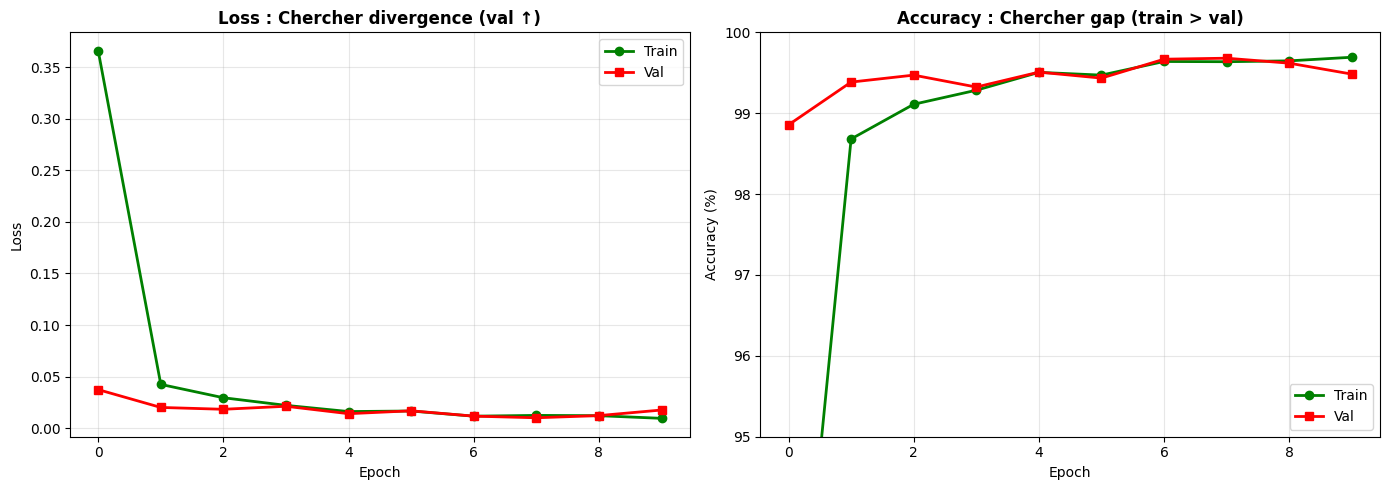

INTERPRÉTATION:
✓ BON : Val loss stable, train ≈ val
✗ MAUVAIS : Val loss ↑, train << val = overfitting


In [3]:
import json
import matplotlib.pyplot as plt

# Charger historique training
with open('/content/drive/MyDrive/AnanthiX_AI/results/training_history.json', 'r') as f:
    history = json.load(f)

print("ANALYSE OVERFITTING")

# Comparer train vs val loss
print("\nTrain vs Val Loss par epoch:")
for epoch, (tl, vl) in enumerate(zip(history['train_loss'], history['val_loss']), 1):
    diff = vl - tl
    symbol = "↑" if diff > 0.01 else "="
    print(f"  Epoch {epoch}: Train {tl:.4f} | Val {vl:.4f} {symbol}")

# Comparer train vs val accuracy
print("\nTrain vs Val Accuracy par epoch:")
for epoch, (ta, va) in enumerate(zip(history['train_acc'], history['val_acc']), 1):
    diff = ta - va
    print(f"  Epoch {epoch}: Train {ta:.2f}% | Val {va:.2f}% (diff: {diff:.2f}%)")

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train', marker='o', linewidth=2, color='green')
axes[0].plot(history['val_loss'], label='Val', marker='s', linewidth=2, color='red')
axes[0].set_title('Loss : Chercher divergence (val ↑)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', marker='o', linewidth=2, color='green')
axes[1].plot(history['val_acc'], label='Val', marker='s', linewidth=2, color='red')
axes[1].set_title('Accuracy : Chercher gap (train > val)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([95, 100])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AnanthiX_AI/results/overfitting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("INTERPRÉTATION:")
print("✓ BON : Val loss stable, train ≈ val")
print("✗ MAUVAIS : Val loss ↑, train << val = overfitting")